# Eksperimen Machine Learning - Credit Risk Dataset

**Nama**: Fikri Dermawan
**Dataset**: Credit Risk (credit_risk_dataset.csv)
**Tanggal**: 2025

Notebook ini merupakan tahap eksperimen awal sebelum otomatisasi pipeline preprocessing.
Mencakup: Data Loading → EDA → Preprocessing → Feature Engineering

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Library berhasil diimport.')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Library berhasil diimport.
Pandas version: 2.3.3
NumPy version: 2.3.5


## 2. Data Loading

In [2]:
# Load dataset dari folder raw
RAW_DATA_PATH = '../credit_risk_dataset_raw.csv'

df = pd.read_csv(RAW_DATA_PATH)

print(f'Dataset berhasil dimuat.')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'\nKolom dataset  : {df.columns.tolist()}')

Dataset berhasil dimuat.
Jumlah baris   : 32,581
Jumlah kolom   : 12

Kolom dataset  : ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']


In [3]:
# Tampilkan 5 baris pertama
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,58,24432.0,MORTGAGE,6.0,DEBTCONSOLIDATION,G,21857.0,22.03,0.89,N,7.0,0
1,48,71488.0,MORTGAGE,4.0,HOMEIMPROVEMENT,C,6544.0,13.36,0.09,N,9.0,0
2,34,109199.0,OTHER,7.0,HOMEIMPROVEMENT,D,34519.0,10.38,0.32,Y,15.0,0
3,62,28953.0,OTHER,6.0,EDUCATION,D,32015.0,11.74,1.11,N,7.0,0
4,27,92833.0,RENT,0.0,MEDICAL,C,14174.0,18.97,0.15,N,25.0,1


In [4]:
# Info tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  float64
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           29875 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  float64
 7   loan_int_rate               29465 non-null  float64
 8   loan_percent_income         32581 non-null  float64
 9   cb_person_default_on_file   32581 non-null  object 
 10  cb_person_cred_hist_length  32581 non-null  float64
 11  loan_status                 32581 non-null  int64  
dtypes: float64(6), int64(2), object(4)
memory usage: 3.0+ MB


In [5]:
# Statistik deskriptif
df.describe(include='all')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
count,32581.000000,32581.000000,32581,29875.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581,32581.000000,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,OWN,NaN,DEBTCONSOLIDATION,B,NaN,NaN,NaN,N,NaN,NaN
freq,NaN,NaN,8191,NaN,5516,4790,NaN,NaN,NaN,26720,NaN,NaN
mean,41.954636,64956.289095,NaN,5.009105,NaN,NaN,17767.070808,14.339552,0.400779,NaN,15.450078,0.218809
std,12.916088,31831.172159,NaN,3.173012,NaN,NaN,9947.095118,5.131827,0.427398,NaN,8.091899,0.413445
min,20.000000,10002.000000,NaN,0.000000,NaN,NaN,501.000000,5.420000,0.000000,NaN,2.000000,0.000000
25%,31.000000,37115.000000,NaN,2.000000,NaN,NaN,9174.000000,9.940000,0.140000,NaN,8.000000,0.000000
50%,42.000000,65020.000000,NaN,5.000000,NaN,NaN,17857.000000,14.300000,0.270000,NaN,15.000000,0.000000
75%,53.000000,92614.000000,NaN,8.000000,NaN,NaN,26345.000000,18.740000,0.480000,NaN,23.000000,0.000000


## 3. Exploratory Data Analysis (EDA)

In [6]:
# Cek nilai yang hilang
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Jumlah Missing', ascending=False)

print('Ringkasan Missing Values:')
print(missing_df[missing_df['Jumlah Missing'] > 0])

Ringkasan Missing Values:
                   Jumlah Missing  Persentase (%)
loan_int_rate                3116            9.56
person_emp_length            2706            8.31


In [7]:
# Cek duplikasi data
duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplikat}')

Jumlah baris duplikat: 0


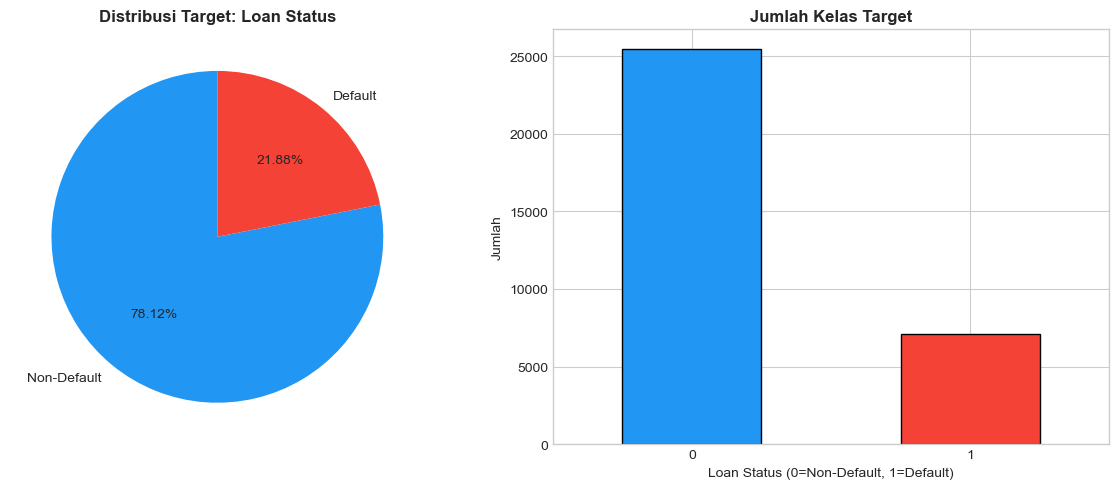

Grafik distribusi target disimpan.


In [8]:
# Distribusi target (loan_status)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['loan_status'].value_counts()
axes[0].pie(target_counts.values,
            labels=['Non-Default', 'Default'],
            autopct='%1.2f%%',
            colors=['#2196F3', '#F44336'],
            startangle=90)
axes[0].set_title('Distribusi Target: Loan Status', fontweight='bold')

target_counts.plot(kind='bar', ax=axes[1], color=['#2196F3', '#F44336'], edgecolor='black')
axes[1].set_title('Jumlah Kelas Target', fontweight='bold')
axes[1].set_xlabel('Loan Status (0=Non-Default, 1=Default)')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik distribusi target disimpan.')

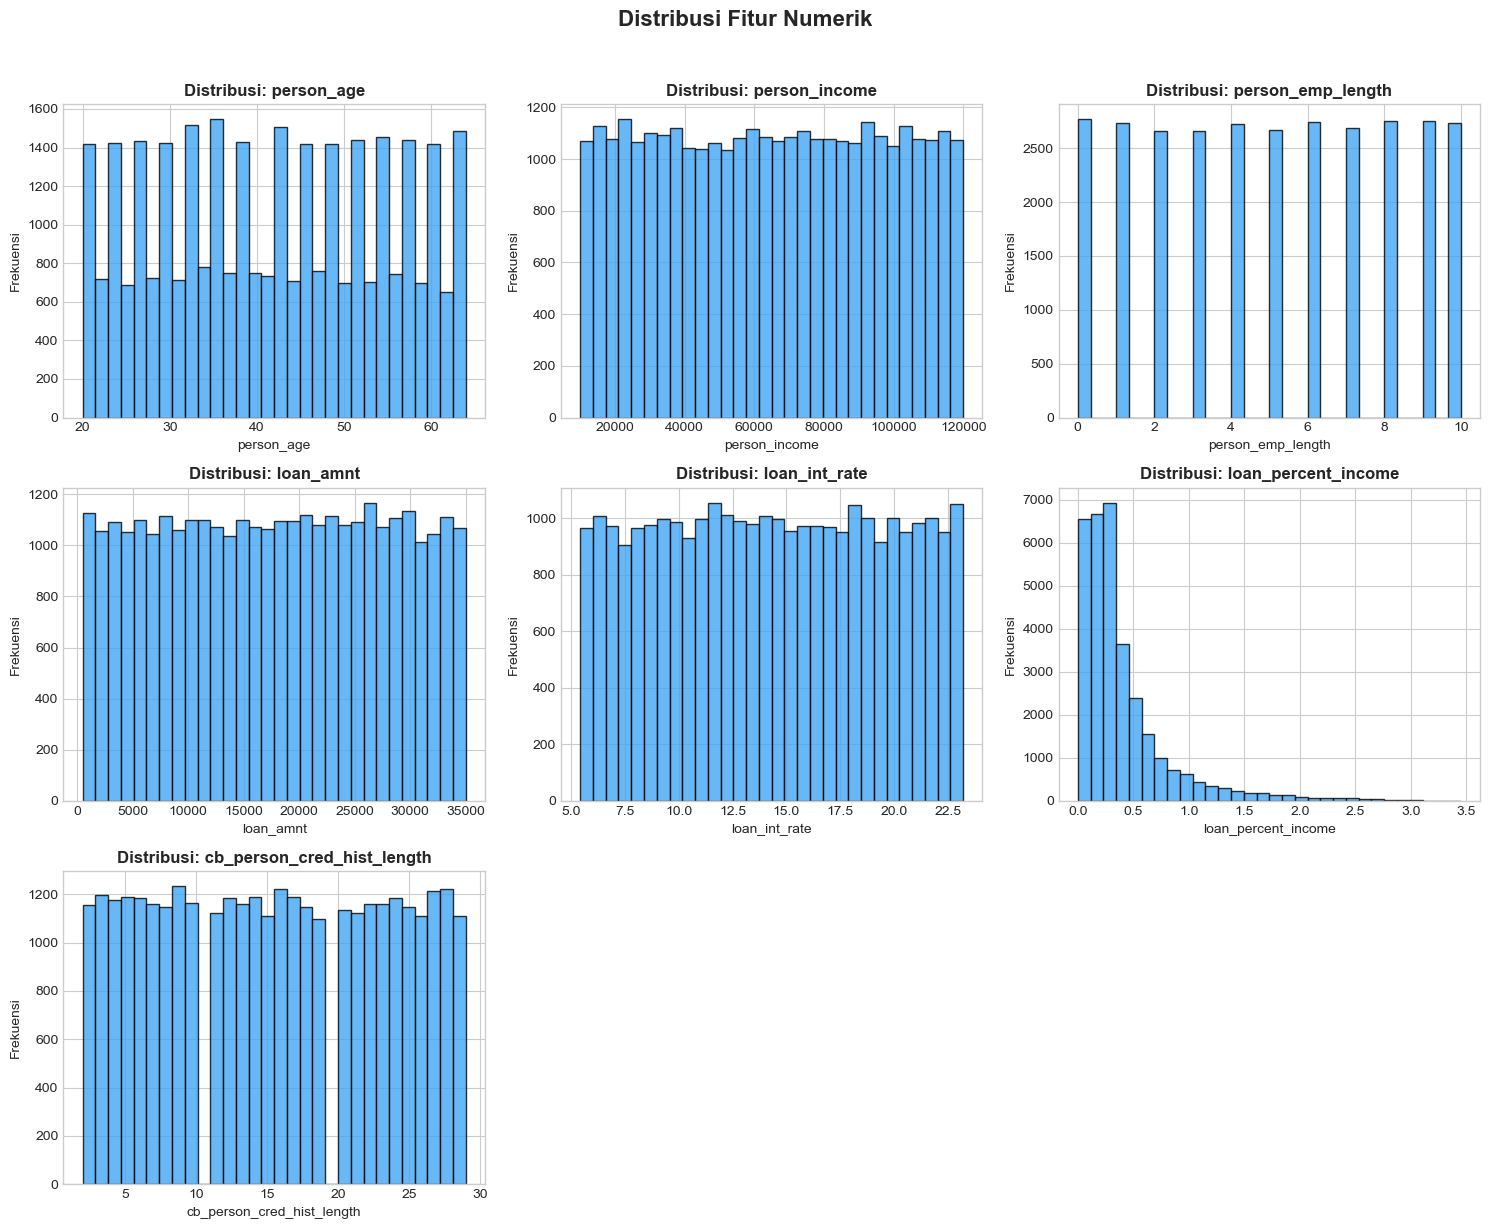

Grafik distribusi numerik disimpan.


In [9]:
# Distribusi fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'loan_status' in numeric_cols:
    numeric_cols.remove('loan_status')

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#42A5F5', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik distribusi numerik disimpan.')

Fitur kategorik: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


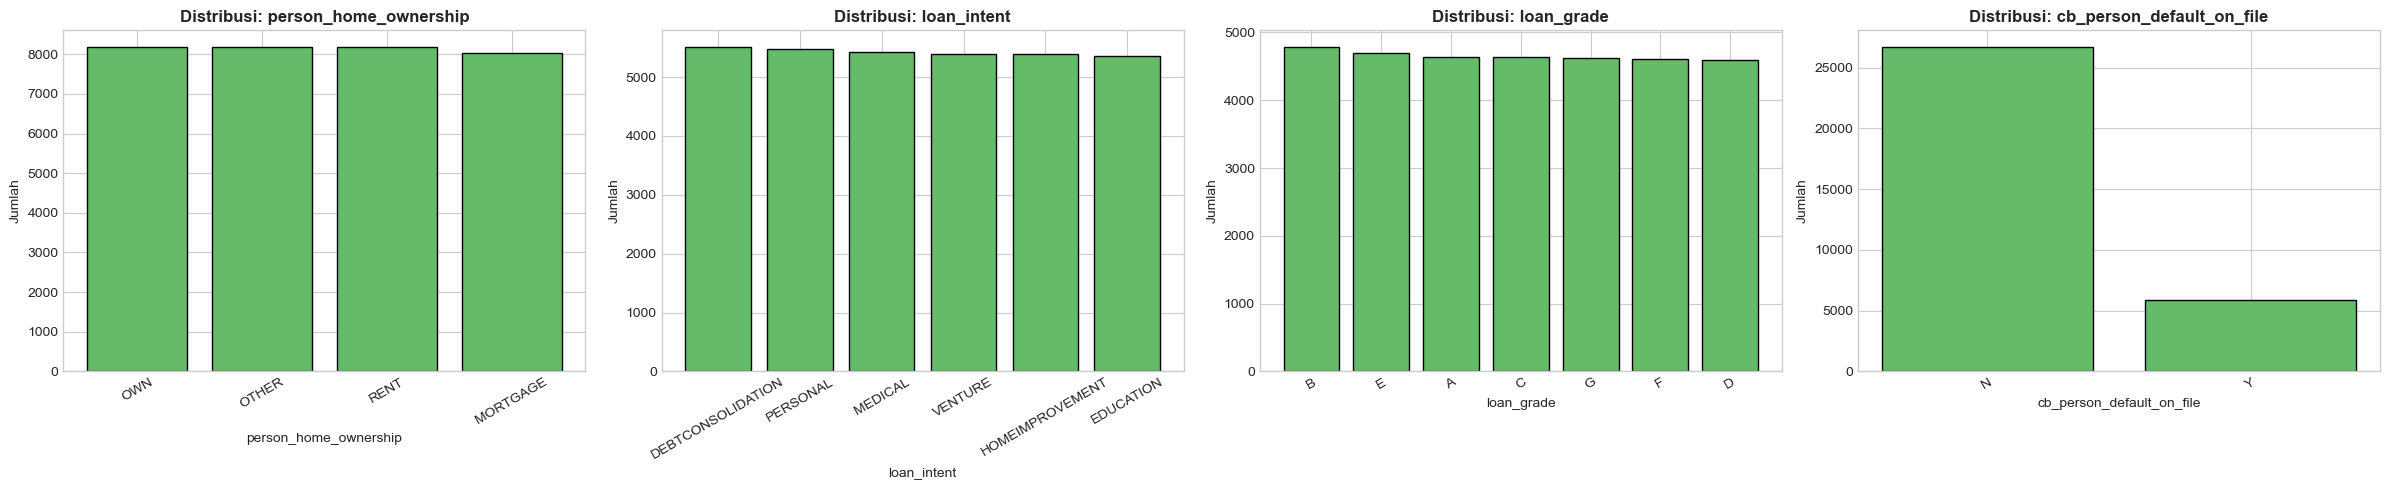

Grafik distribusi kategorik disimpan.


In [10]:
# Distribusi fitur kategorik
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Fitur kategorik: {categorical_cols}')

if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6 * len(categorical_cols), 5))
    if len(categorical_cols) == 1:
        axes = [axes]

    for i, col in enumerate(categorical_cols):
        counts = df[col].value_counts()
        axes[i].bar(counts.index, counts.values, color='#66BB6A', edgecolor='black')
        axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Jumlah')
        axes[i].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('distribusi_kategorik.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafik distribusi kategorik disimpan.')

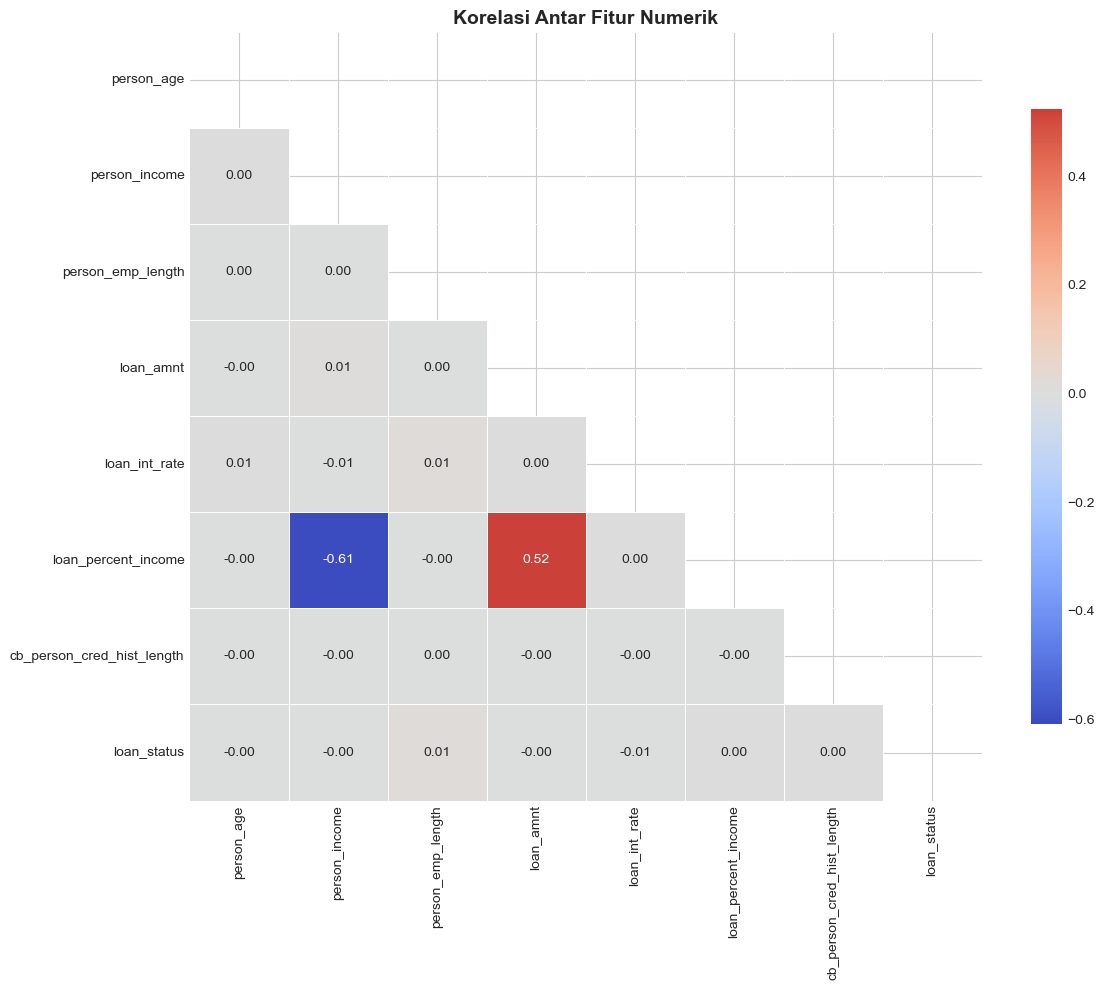

Heatmap korelasi disimpan.


In [11]:
# Korelasi antar fitur numerik
corr_matrix = df[numeric_cols + ['loan_status']].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap korelasi disimpan.')

In [12]:
# Deteksi outlier menggunakan IQR
print('Deteksi Outlier (IQR Method):')
print('-' * 40)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (n_outlier / len(df)) * 100
    print(f'{col:35s}: {n_outlier:5d} outlier ({pct:.2f}%)')

Deteksi Outlier (IQR Method):
----------------------------------------
person_age                         :     0 outlier (0.00%)
person_income                      :     0 outlier (0.00%)
person_emp_length                  :     0 outlier (0.00%)
loan_amnt                          :     0 outlier (0.00%)
loan_int_rate                      :     0 outlier (0.00%)
loan_percent_income                :  2652 outlier (8.14%)
cb_person_cred_hist_length         :     0 outlier (0.00%)


## 4. Preprocessing

In [13]:
# Salin dataframe agar data asli tidak termodifikasi
df_clean = df.copy()

# 4.1 Hapus baris duplikat
sebelum = len(df_clean)
df_clean.drop_duplicates(inplace=True)
sesudah = len(df_clean)
print(f'Duplikat dihapus: {sebelum - sesudah} baris')

Duplikat dihapus: 0 baris


In [14]:
# 4.2 Imputasi missing values
# Fitur numerik: median (robust terhadap outlier)
# Fitur kategorik: modus

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'[NUMERIK]  {col} → imputasi median: {median_val:.4f}')

for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'[KATEGORI] {col} → imputasi modus: {mode_val}')

print(f'\nTotal missing setelah imputasi: {df_clean.isnull().sum().sum()}')

[NUMERIK]  person_emp_length → imputasi median: 5.0000
[NUMERIK]  loan_int_rate → imputasi median: 14.3000

Total missing setelah imputasi: 0


In [15]:
# 4.3 Encoding fitur kategorik menggunakan Label Encoder
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'Encoding selesai: {col}')

print(f'\nTotal fitur setelah encoding: {df_clean.shape[1]}')

Encoding selesai: person_home_ownership
Encoding selesai: loan_intent
Encoding selesai: loan_grade
Encoding selesai: cb_person_default_on_file

Total fitur setelah encoding: 12


In [16]:
# 4.4 Penanganan outlier menggunakan Capping (IQR Winsorizing)
feature_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c != 'loan_status']

for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print('Outlier capping selesai pada semua fitur numerik.')

Outlier capping selesai pada semua fitur numerik.


In [17]:
# 4.5 Pisahkan fitur dan target
TARGET_COL = 'loan_status'
X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

print(f'Dimensi X (fitur) : {X.shape}')
print(f'Dimensi y (target): {y.shape}')
print(f'Distribusi target :\n{y.value_counts()}')

Dimensi X (fitur) : (32581, 11)
Dimensi y (target): (32581,)
Distribusi target :
loan_status
0    25452
1     7129
Name: count, dtype: int64


In [18]:
# 4.6 Standarisasi fitur menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Standarisasi selesai.')
print(X_scaled.describe().round(4))

Standarisasi selesai.
       person_age  person_income  person_home_ownership  person_emp_length  \
count  32581.0000     32581.0000             32581.0000         32581.0000   
mean      -0.0000        -0.0000                -0.0000             0.0000   
std        1.0000         1.0000                 1.0000             1.0000   
min       -1.6998        -1.7265                -1.3509            -1.6484   
25%       -0.8482        -0.8747                -0.4546            -0.9901   
50%        0.0035         0.0020                 0.4416            -0.0027   
75%        0.8552         0.8689                 1.3379             0.9846   
max        1.7068         1.7289                 1.3379             1.6429   

       loan_intent  loan_grade   loan_amnt  loan_int_rate  \
count   32581.0000  32581.0000  32581.0000     32581.0000   
mean       -0.0000      0.0000      0.0000         0.0000   
std         1.0000      1.0000      1.0000         1.0000   
min        -1.4598     -1.4943 

In [19]:
# 4.7 Split data: Train 80% - Test 20% (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Data training  : {X_train.shape[0]:,} sampel')
print(f'Data testing   : {X_test.shape[0]:,} sampel')

Data training  : 26,064 sampel
Data testing   : 6,517 sampel


In [20]:
# 4.8 Simpan hasil preprocessing
OUTPUT_DIR = 'credit_risk_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
X_test.to_csv(f'{OUTPUT_DIR}/X_test.csv', index=False)
y_train.to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
y_test.to_csv(f'{OUTPUT_DIR}/y_test.csv', index=False)

print(f'Dataset preprocessing disimpan ke folder: {OUTPUT_DIR}/')
print('File yang dihasilkan:')
for f in os.listdir(OUTPUT_DIR):
    print(f'  - {f}')

Dataset preprocessing disimpan ke folder: credit_risk_preprocessing/
File yang dihasilkan:
  - X_test.csv
  - X_train.csv
  - y_test.csv
  - y_train.csv


## 5. Ringkasan Eksperimen

In [21]:
print('='*55)
print('         RINGKASAN EKSPERIMEN PREPROCESSING')
print('='*55)
print(f'Dataset awal       : {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'Dataset setelah    : {df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom')
print(f'Fitur              : {X.shape[1]} kolom')
print(f'Data training      : {X_train.shape[0]:,} sampel')
print(f'Data testing       : {X_test.shape[0]:,} sampel')
print('='*55)
print('Tahapan preprocessing:')
print('  1. Hapus duplikasi data')
print('  2. Imputasi missing values (median/modus)')
print('  3. Encoding fitur kategorik (Label Encoder)')
print('  4. Capping outlier (IQR Winsorizing)')
print('  5. Standarisasi fitur (StandardScaler)')
print('  6. Train-Test Split (80:20, stratified)')
print('='*55)

         RINGKASAN EKSPERIMEN PREPROCESSING
Dataset awal       : 32,581 baris x 12 kolom
Dataset setelah    : 32,581 baris x 12 kolom
Fitur              : 11 kolom
Data training      : 26,064 sampel
Data testing       : 6,517 sampel
Tahapan preprocessing:
  1. Hapus duplikasi data
  2. Imputasi missing values (median/modus)
  3. Encoding fitur kategorik (Label Encoder)
  4. Capping outlier (IQR Winsorizing)
  5. Standarisasi fitur (StandardScaler)
  6. Train-Test Split (80:20, stratified)
